# Curating DRVI factor annotations

The integrative step: for each factor-direction, compare **all** tools' outputs and assign a
final label.

This notebook reloads `embed` from disk and reads whatever the other notebooks stored in 
`embed.uns` / `embed.var`. Tools whose notebook you did not run simply show "(not run)".

For each factor: `inspect(...)` prints all evidence, `plot_factor_summary(...)` shows its UMAP
pattern and top genes, `inspect_marker_gene(...)` tests a specific gene. Record decisions in
`MANUAL_LABELS`.

> This is one of four companion notebooks. Run whichever of
> [cell types](./identification_of_factors_1_cell_types.html),
> [biological processes](./identification_of_factors_2_biological_processes.html), and
> [LLM tools](./identification_of_factors_3_llm_tools.html) you need first — they each store
> results into the same `embed.h5ad` that this notebook reads.

## Contact

Questions: [scverse discourse](https://discourse.scverse.org/). Bugs:
[issue tracker](https://github.com/theislab/drvi/issues).

## Prerequisites

Run one or more of the companion notebooks first so that `embed.h5ad` contains their stored
results. This notebook needs only the base dependencies (`drvi`, `scanpy`) from
`requirements.txt` — no LLM or enrichment packages.

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc
import pandas as pd
import anndata as ad
import drvi
from drvi.model import DRVI
from pathlib import Path

## Setup

In [3]:
# Input/output directory holding the trained model and embeddings. Update accordingly.
io_dir = Path("./tmp_io/drvi_immune_128/").resolve()

embed_path = io_dir / "embed.h5ad"
adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")
embed = sc.read_h5ad(embed_path)
model = DRVI.load(io_dir / "drvi_model", adata)
scores_df = model.get_interpretability_scores(embed, adata, key="OOD_combined")

drvi_score_cutoff = 0.1
annot_col = "final_annotation"

INFO     File /Users/amir/projects/drvi_tutorials/tmp_io/drvi_immune_128/drvi_model/model.pt already downloaded    


INFO     DRVI: The model is trained with DRVI version 0.2.5.                                                       


INFO     DRVI: Updaging data setup config ...                                                                      


INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.6.                                  


INFO     DRVI: Loading model from DRVI version 0.2.5.                                                              


INFO     DRVI: Done updating model args. Loading in 0.2.6.                                                         


INFO     DRVI: The model has been initialized                                                                      


## Config: which stored results to show

In [4]:
# Top-N terms shown per enrichment tool.
CURATION_TOP_N = {"gseapy_enrichr": 3, "gprofiler": 5, "decoupler": 1}

ENRICHMENT_TOOLS = [
    ("gseapy_enrichr", "gseapy_enrichr_results", "Term"),
    ("gprofiler",      "gprofiler_results",      "name"),
    ("decoupler",      "decoupler_results",      "term"),
]

# LLM tools — populated only if you ran the LLM notebook; otherwise shown as None.
LLM_TOOLS = [
    ("llm celltype",   "llm_direct_results", "cell_type"),
    ("llm process",    "llm_direct_results", "biological_process"),
    ("cassia general", "cassia_results",     "Predicted General Cell Type"),
    ("cassia detailed", "cassia_results",    "Predicted Detailed Cell Type"),
    ("gs2txt",         "gs2txt_results",     "description"),
]

# Cell-type SMI matches written by the cell-types notebook (matching column names).
VAR_ANNOTATIONS = [
    ("known (SMI)", "positive_direction_match_with_user_annotations",
                    "negative_direction_match_with_user_annotations"),
    ("celltypist",  "positive_direction_match_with_celltypist",
                    "negative_direction_match_with_celltypist"),
]

## Inspection helpers

In [5]:
def _var_value(embed, col, factor_title):
    if col not in embed.var.columns:
        return None
    row = embed.var.loc[embed.var["title"] == factor_title, col].dropna()
    return row.iloc[0] if not row.empty else None


def _uns_value(embed, key, col, factor, direction):
    df = embed.uns.get(key, pd.DataFrame())
    if df.empty or col not in df.columns:
        return None
    if "direction" in df.columns:
        mask = (df["factor"] == factor) & (df["direction"] == direction)
    else:
        mask = df["factor"] == f"{factor}{direction}"
    sub = df.loc[mask, col].dropna()
    return sub.iloc[0] if not sub.empty else None

In [6]:
def inspect(factor_label, embed, scores_df=scores_df, cutoff=drvi_score_cutoff):
    """Print a summary of all annotation tools for a single factor-direction."""
    factor, direction = factor_label[:-1].strip(), factor_label[-1]
    suf = "positive" if direction == "+" else "negative"
    print(f"\n{'=' * 60}\n  {factor_label}\n{'=' * 60}")

    print(f"\n- Manual -\n  {_var_value(embed, f'{suf}_direction_manual_label', factor)}")

    n_passing = (scores_df[factor_label] >= cutoff).sum()
    if n_passing == 0:
        print("\nNo genes above cutoff - uninformative direction.")
        return

    print(f"\nTop 10 genes ({n_passing} above cutoff):")
    for g, s in scores_df[factor_label].sort_values(ascending=False).head(10).items():
        print(f"  {g:<15} {s:.3f}")

    print("\n- Known / CellTypist -")
    for label, pos_col, neg_col in VAR_ANNOTATIONS:
        print(f"  {label:<18} {_var_value(embed, pos_col if direction == '+' else neg_col, factor)}")

    print("\n- LLM tools -")
    for label, key, col in LLM_TOOLS:
        print(f"  {label:<18} {_uns_value(embed, key, col, factor, direction)}")

    print("\n- Enrichment tools -")
    for label, key, term_col in ENRICHMENT_TOOLS:
        df = embed.uns.get(key, pd.DataFrame())
        if df.empty or term_col not in df.columns:
            print(f"  {label}: (not run)")
            continue
        hits = df[df["factor"] == factor_label][term_col].head(CURATION_TOP_N[label]).tolist() or ["(no hits)"]
        print(f"  {label}:\n" + "\n".join(f"    - {h}" for h in hits))

In [7]:
def plot_factor_summary(factor_label, embed, adata, scores_df, annot_col="final_annotation", n_genes=4):
    adata.obsm["X_drvi_umap"] = embed[adata.obs.index].obsm["X_umap"]
    drvi.utils.pl.plot_latent_dims_in_umap(
        embed, dim_subset=[factor_label], directional=True, additional_columns=[annot_col]
    )
    top = scores_df[factor_label].sort_values(ascending=False).index.to_list()[:n_genes]
    sc.pl.embedding(adata, "X_drvi_umap", color=top)

In [8]:
def inspect_marker_gene(gene, embed, adata, scores_df=scores_df, top_n=10):
    adata.obsm["X_drvi_umap"] = embed[adata.obs.index].obsm["X_umap"]
    sc.pl.embedding(adata, "X_drvi_umap", color=gene, cmap="viridis")
    print(f"Top {top_n} factors for gene '{gene}':")
    print(scores_df.loc[gene].sort_values(ascending=False).head(top_n))

## Go factor by factor


  DR 43-

- Manual -
  Interferon response

Top 10 genes (76 above cutoff):
  CXCL10          14.917
  CCL8            14.042
  IFIT1           9.182
  IFIT3           7.573
  IFIT2           5.997
  ISG15           5.139
  RSAD2           5.053
  IFI44L          4.233
  APOBEC3A        3.243
  HERC5           3.017

- Known / CellTypist -
  known (SMI)        None
  celltypist         None

- LLM tools -
  llm celltype       interferon-responsive immune cells (myeloid/monocyte bias, but broadly ISG-high state rather than one lineage)
  llm process        type I interferon (antiviral) response — ISG induction
  cassia general     Inflammatory Monocytes
  cassia detailed    Inflammatory/Activated Classical Monocytes (CD14+), Inflammatory Monocyte-derived Dendritic Cells (mo-DCs), Plasmacytoid Dendritic Cells (pDCs)
  gs2txt             The perturbed genes collectively orchestrate a robust interferon-mediated antiviral innate immune response, characterized by the coordinated upregulatio

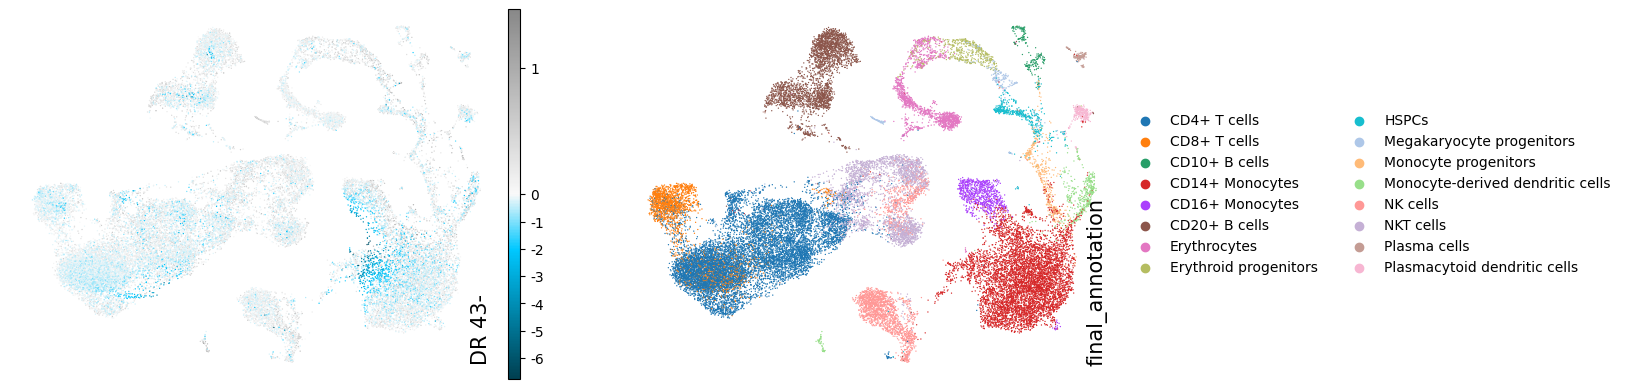

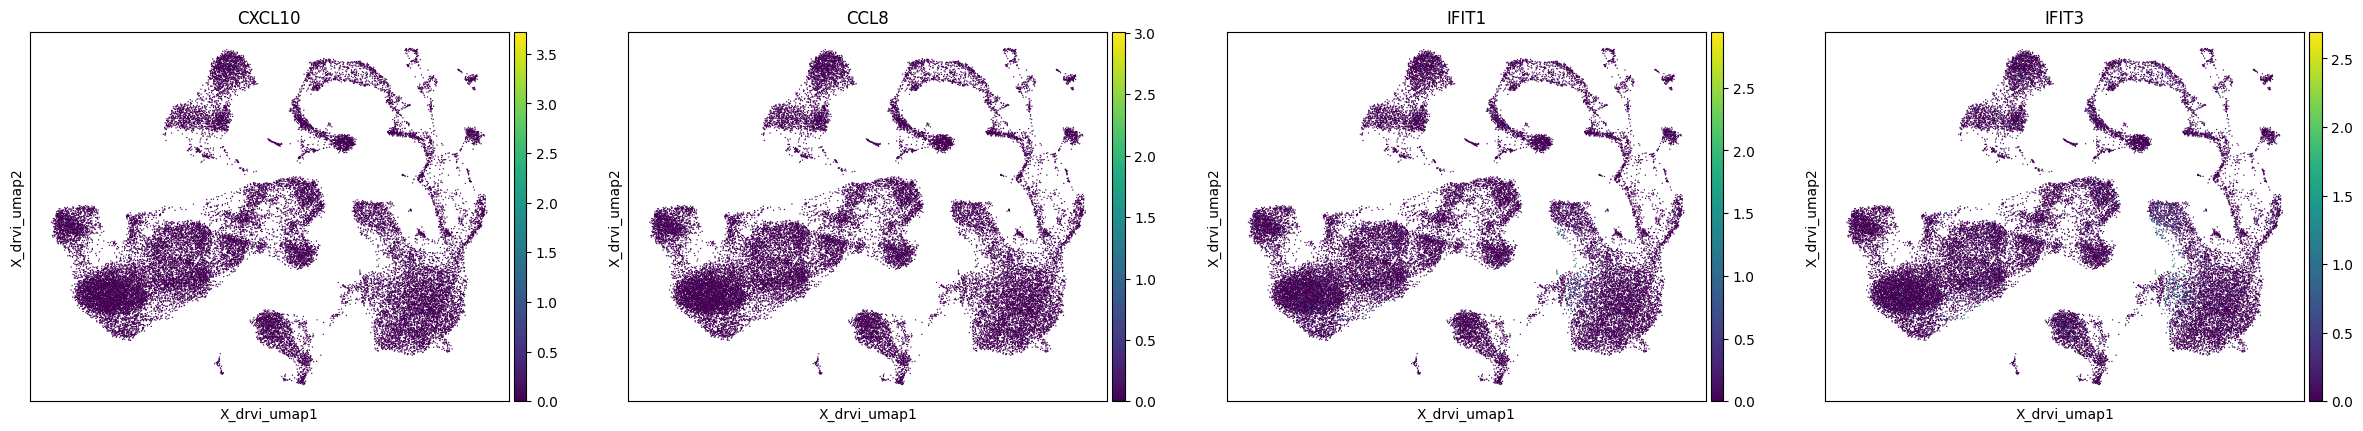

In [9]:
factor_label = "DR 43-"
inspect(factor_label, embed)
plot_factor_summary(factor_label, embed, adata, scores_df)

### Inspect a marker gene

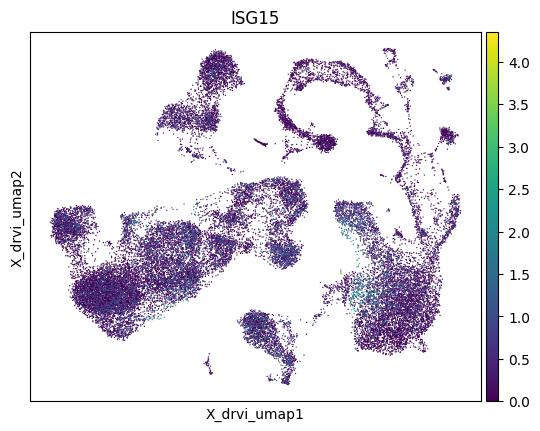

Top 10 factors for gene 'ISG15':
title
DR 43-    5.138990
DR 1-     0.138256
DR 9-     0.127650
DR 55-    0.108796
DR 10+    0.075751
DR 53+    0.062952
DR 27-    0.060177
DR 25+    0.047311
DR 6+     0.039649
DR 3+     0.037884
Name: ISG15, dtype: float32


In [10]:
marker_gene = "ISG15"
inspect_marker_gene(marker_gene, embed, adata)

## Record manual decisions

In [11]:
MANUAL_LABELS = {
    "DR 43-": "Interferon response",
}

## Write manual labels back

In [12]:
for d, suf in [("+", "positive"), ("-", "negative")]:
    mapping = {k[:-1].strip(): v for k, v in MANUAL_LABELS.items() if k.endswith(d)}
    embed.var[f"{suf}_direction_manual_label"] = embed.var["title"].map(mapping)

ad.settings.allow_write_nullable_strings = True
embed.write_h5ad(embed_path)
print(f"Saved to: {embed_path}")

Saved to: /Users/amir/projects/drvi_tutorials/tmp_io/drvi_immune_128/embed.h5ad
